# Nivell 1

Connecta Python amb MySQL Workbench i carrega les dades de la teva base de dades del Sprint 4 per utilitzar-les en tots els exercicis.

Començem instalant les llibreries faltants, en el meu cas la conexio amb mySQL amb "pip install mysql-connector-python"

In [112]:
import pandas as pd
import mysql.connector
from mysql.connector import Error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 1. Connecta Python amb MySQL Workbench i carrega les dades de la teva base de dades del Sprint 4 per utilitzar-les en tots els exercicis.

In [93]:
connection_config_dict = {
        'user': 'root',
        'password': 'root',
        'host': '127.0.0.1',
        'database': 'sprint4',
        'raise_on_warnings': True,
        'use_pure': False,
        'autocommit': True,
        'pool_size': 5
    }
connection = mysql.connector.connect(**connection_config_dict)

In [94]:
users = pd.read_sql('select * from users', connection )
transactions = pd.read_sql('select * from transactions', connection )
products = pd.read_sql('select * from products', connection )
companies = pd.read_sql('select * from companies', connection )
credit_card = pd.read_sql('select * from credit_cards', connection )
transaction_products = pd.read_sql('select * from transaction_products', connection )


C:\Users\nowan\AppData\Local\Temp\ipykernel_30376\1304597527.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  users = pd.read_sql('select * from users', connection )
C:\Users\nowan\AppData\Local\Temp\ipykernel_30376\1304597527.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  transactions = pd.read_sql('select * from transactions', connection )
C:\Users\nowan\AppData\Local\Temp\ipykernel_30376\1304597527.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  products = pd.read_sql('select * from products', connection )
C:

## 2. Per a cada ítem, crea una visualització adequada segons les variables especificades. Interpreta els resultats segons les teves dades.

Recorda: quan seleccionis les columnes, pensa sempre en el mètode que faràs servir i inclou les que calguin per a la funció de visualització que vulguis utilitzar.

### Una variable numèrica.

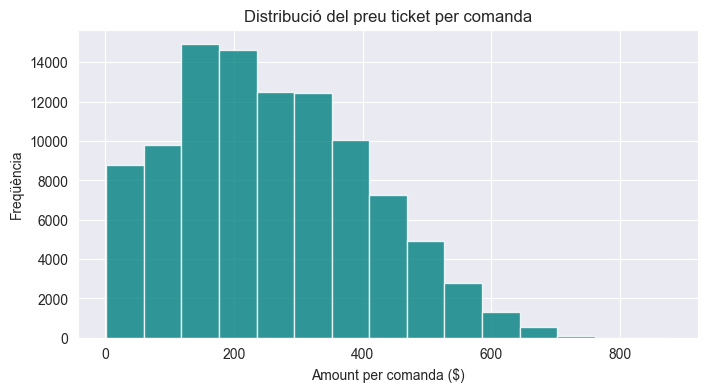

In [95]:
fig, ax = plt.subplots(figsize = (8,4) )

ax.hist(transactions.amount.dropna(), bins=15, color="teal", alpha=0.8, edgecolor="white")

ax.set_xlabel("Amount per comanda ($)")
ax.set_ylabel("Freqüència")
ax.set_title("Distribució del preu ticket per comanda")

plt.show()

Interpretació de la gràfica: En aquest histograma on podem veure la distribució, segons el preu de ticket, podem descubrir que es presenta esbiaixada cap a la dreta, concentrant el major nombre de compres entre els 150$ i 200$, i baixant progressivament a mida que ens acostem al ticket maxim.

### Dues variables numèriques.

In [96]:
products["price"] = products["price"].str.replace("$", "", regex=False)
products["price"] = pd.to_numeric(products["price"])
vendes = transaction_products["product_id"].value_counts().reset_index()
vendes.columns = ["product_id", "vendes"]

vendes = vendes.merge(products[["id", "price"]], 
                      left_on="product_id",   # columna a vendes
                      right_on="id",          # columna a products
                      how="left")
vendes["Total"] = vendes.vendes * vendes.price

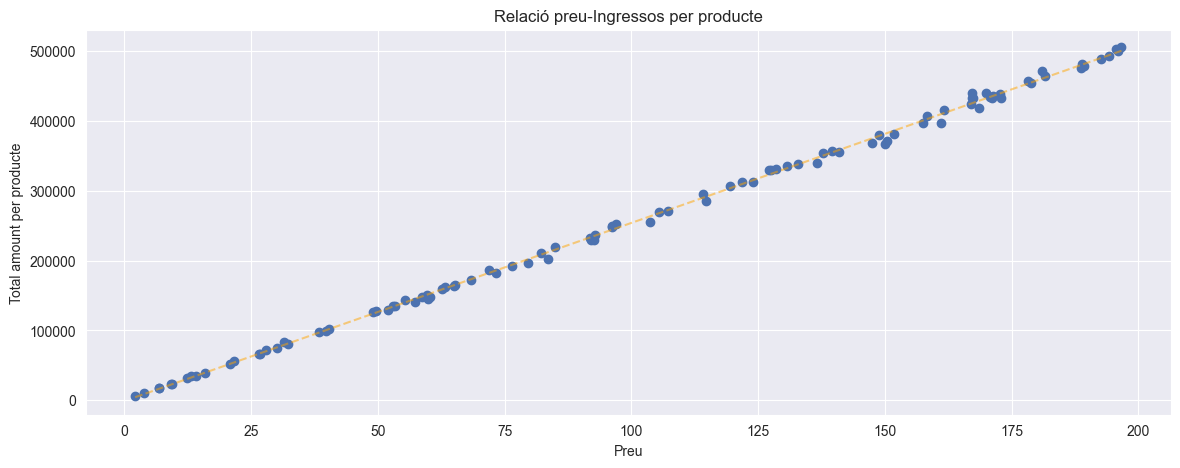

In [97]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.scatter(vendes.price, vendes.Total, marker='o', label='Circle')

m, b = np.polyfit(vendes["price"], vendes["Total"], 1)
x = np.linspace(vendes["price"].min(), vendes["price"].max(), 100)
ax.plot(x, m * x + b, color="orange", linewidth=1.5, linestyle="--", label="Tendència", alpha = 0.5)

plt.xlabel("Preu")
plt.ylabel("Total amount per producte")
plt.title("Relació preu-Ingressos per producte")


plt.show()

Despres de les conversions pertinents, per obtindre el total venut per producte, optem per un digrama de dispersió, per observar si ha una relació entre el preu del producte i el que aporta a l'empresa. Descubrim una correlació positiva molt forta: La diagonal ascendent mostra que son els productes mes cars, el que més ingressos generen. Al llarg de tota la relació, es manté la proporcio preu-ingressos i no s'hi observa cap excepció destacable.

### Una variable categòrica.

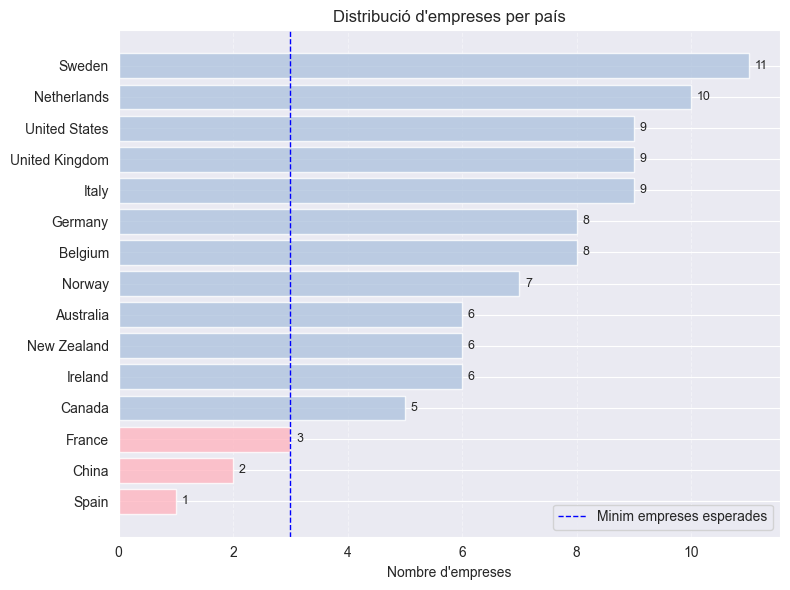

In [98]:
counts = companies["country"].value_counts()

fig, ax = plt.subplots(figsize=(8, 6))

colors = ["lightsteelblue" if v > 3 else "lightpink" for v in counts.values]
ax.barh(counts.index, counts.values, color=colors, alpha=0.8, edgecolor="white")

# etiquetes amb el valor a la dreta de cada barra
for i, v in enumerate(counts.values):
    ax.text(v + 0.1, i, str(v), va="center", fontsize=9)

ax.set_xlabel("Nombre d'empreses")
ax.set_title("Distribució d'empreses per país")
ax.invert_yaxis() 
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.axvline(x=3, color='blue', linestyle='--', linewidth=1, label='Minim empreses esperades')
plt.legend()
plt.tight_layout()
plt.show()

Avaluem la distribució geogràfica d'empreses, mitjançant una gràfica de barres horitzontals. 

Retornant a l'enunciat d'exercicis anteriors, repliquem el valor de tall, establert per l'empresa, de 3 empreses per país, i mostrem una línia de referència i color condicional, en cas que no superin aquest llindar. 
Només tres països queden per sota del llindar (França, Xina i Espanya), que suggereix una presència feble en aquests mercats, però caldria analitzar el volum de vendes, per veure quin impacte econòmic generen a nivell global, i si les vendes estan més concentrades en un nombre menor d'empreses.

### Una variable categòrica i una numèrica.

In [99]:
recompte_usuaris = users["country"].value_counts()

In [100]:
companies_amount = transactions.groupby("business_id")["amount"].sum().reset_index()

companies_amount = companies_amount.merge(companies[["company_id", "country"]], 
                      left_on="business_id",
                      right_on="company_id",
                      how="left")

country_amount = companies_amount.groupby("country")["amount"].sum().reset_index()

country_amount = country_amount.sort_values("amount", ascending=False)


country_amount["amount_k"] = country_amount["amount"] / 1000

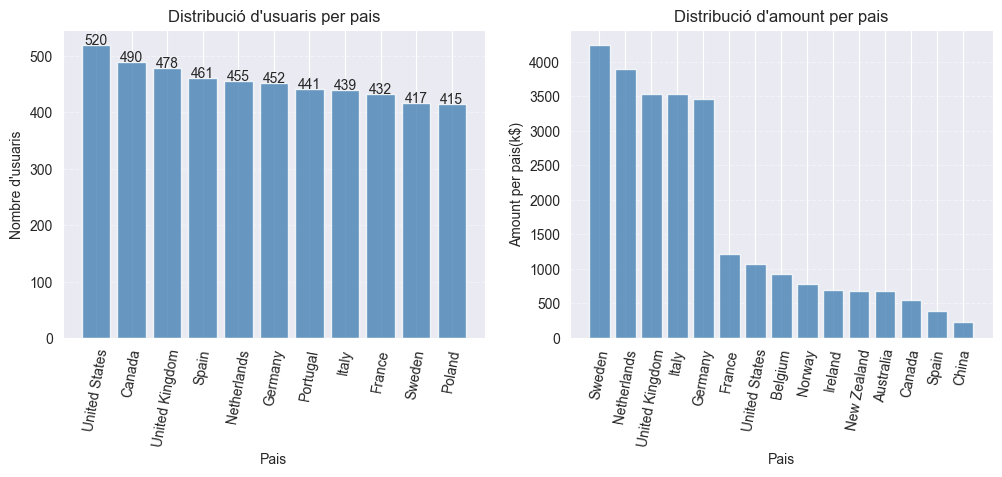

In [101]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 4))

ax[0].bar(recompte_usuaris.index, recompte_usuaris.values, color="steelblue", alpha=0.8)

for i, v in enumerate(recompte_usuaris.values):
    ax[0].text(i, v + 0.5, str(v), ha="center", fontsize=10)

ax[0].set_xlabel("Pais")
ax[0].set_ylabel("Nombre d'usuaris")
ax[0].set_title("Distribució d'usuaris per pais")
ax[0].grid(axis="y", linestyle="--", alpha=0.4)

ax[0].tick_params(axis="x", rotation=80)


ax[1].bar(country_amount["country"], country_amount["amount_k"], color="steelblue", alpha=0.8)

ax[1].set_xlabel("Pais")
ax[1].set_ylabel("Amount per pais(k$)")
ax[1].set_title("Distribució d'amount per pais")
ax[1].grid(axis="y", linestyle="--", alpha=0.4)

ax[1].tick_params(axis="x", rotation=80)


plt.show()

Seguint investigant sobre la distribució geogràfica, indaguem sobre els usuaris, amb una nova gràfica de barres, aquest cop verticals, que demostra que la diferència d'usuaris per país, es poc notable.

Continuem l'anàlisi de la distribució geogràfica, aprofitant la funcionalitat de subplots de matplotlib per representar dues gràfiques en un mateix espai visual.

En la segona gràfica, si que observem diferències notables entre la suma de transaccions en els diversos països. 

### Dues variables categòriques.

In [102]:
df_heatmap = transactions.merge(users[["id", "country"]], 
                        left_on="user_id", 
                        right_on="id", 
                        how="left").rename(columns={"country": "country_user"})

df_heatmap = df_heatmap.merge(companies[["company_id", "country"]], 
              left_on="business_id", 
              right_on="company_id", 
              how="left").rename(columns={"country": "country_company"})


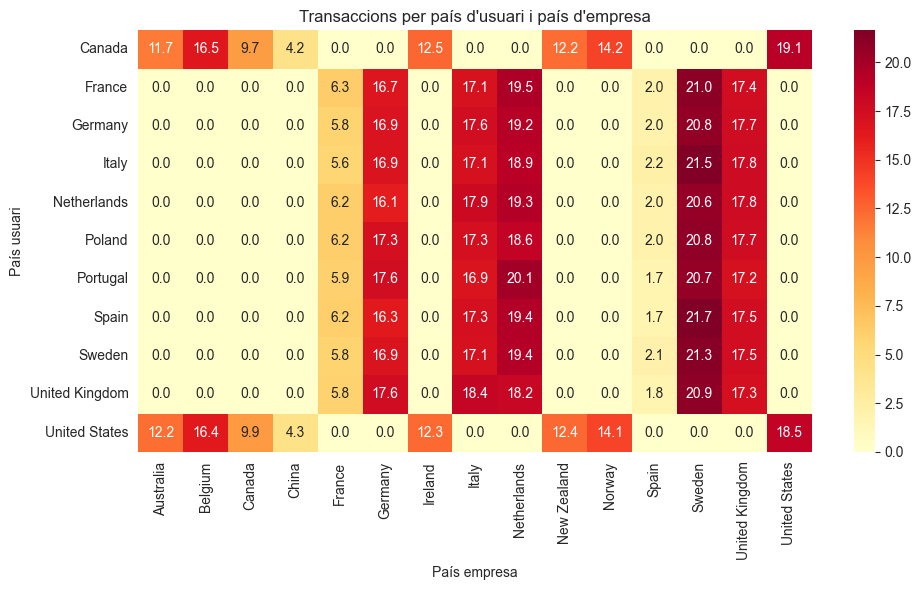

In [103]:
contingencia = pd.crosstab(df_heatmap["country_user"], df_heatmap["country_company"])
contingencia_norm = pd.crosstab(df_heatmap["country_user"], 
                                 df_heatmap["country_company"], 
                                 normalize="index") * 100

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(contingencia_norm, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax)

ax.set_xlabel("País empresa")
ax.set_ylabel("País usuari")
ax.set_title("Transaccions per país d'usuari i país d'empresa")

plt.tight_layout()
plt.show()

Després de crear la matriu per veure la relació entre el país dels usuaris i el de les empreses on compren, procedim creant un mapa de calor, normalitzat per files, per establirne una relació visual. 

Això ens permet veure la distribució d'aquesta relació, on s'observen dos blocs de mercat completament separats. Els usuaris nord-americans (EEUU i Canada), concentren les seves compres en un bloc de països no europeus (amb l'excepció de Noruega i Bèlgica), mentre que els europeus ho fan en el propi mercat. 

Els zeros per la seva banda, remarquen la segmentació geogràfica del mercat en dos blocs clars, sense cap solapament.

### Tres variables combinades.

In [104]:
empresa_resum = transactions.groupby("business_id").agg(
    num_transaccions=("amount", "count"),
    amount_mitja=("amount", "mean")
).reset_index()


empresa_resum = empresa_resum.merge(companies[["company_id", "country", "company_name"]], 
                                     left_on="business_id", 
                                     right_on="company_id", 
                                     how="left")


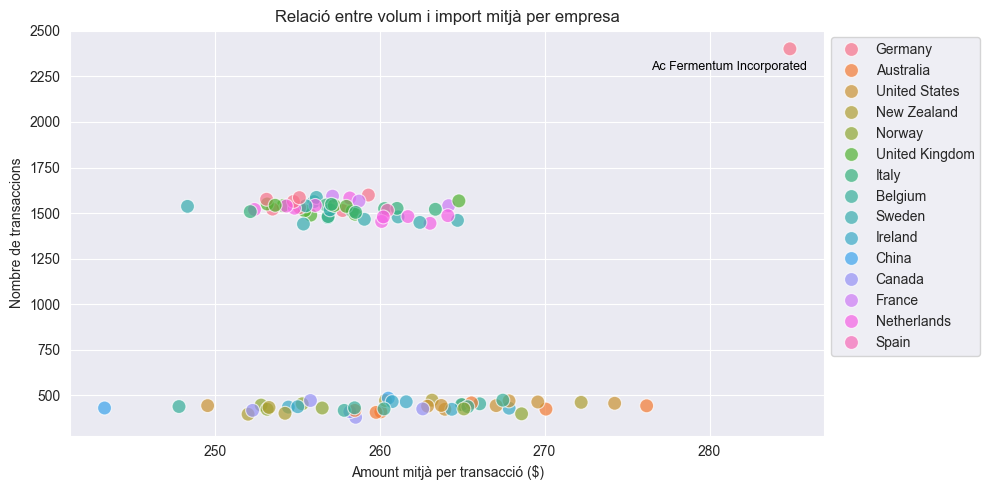

In [105]:
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(10, 5))

sns.scatterplot(data=empresa_resum, 
                x="amount_mitja", 
                y="num_transaccions", 
                hue="country",    
                alpha=0.7,
                s=100,            
                ax=ax)

outlier = empresa_resum.loc[empresa_resum["num_transaccions"].idxmax()]

ax.annotate(outlier["company_name"],
            xy=(outlier["amount_mitja"], outlier["num_transaccions"]),
            xytext=(-100, -15),             
            textcoords="offset points",
            fontsize=9,
            color="black")

ax.set_xlabel("Amount mitjà per transacció ($)")
ax.set_ylabel("Nombre de transaccions")
ax.set_title("Relació entre volum i import mitjà per empresa")
ax.legend(bbox_to_anchor=(1, 1), loc="upper left")  

plt.tight_layout()
plt.show()

Ara, anem a aprofundir en les empreses, situant-les en una gràfica de dispersió, a través de la relació entre el nombre de transaccions i la mitjana del ticket d'aquestes.
Com a tercera variable, afegirem color per a situar cada empresa geogràficament.
Hi podem observar dos grans blocs, un amb un nombre de transaccions per sota de les 500 i un segon bloc al voltant de les 1500. No s'observa un patró geogràfic clar dins de cada bloc.

A banda, hi trobem un outlier d'una empresa alemanya (Ac Fermentum Incorporated), que hem etiquetat per a destacar-la, que supera la resta en els dos eixos, amb prop de 2400 transaccions i una mitjana de ticket superior als 285$. 

### Crea un Pairplot.

In [106]:

empresa_resum2 = transactions.groupby("business_id").agg(
    num_transaccions=("amount", "count"),
    amount_mitja=("amount", "mean"),
    amount_max=("amount", "max"),
    num_usuaris=("user_id", "nunique")
).reset_index()

empresa_resum2["total_ingressos"] = empresa_resum2["amount_mitja"] * empresa_resum2["num_transaccions"]


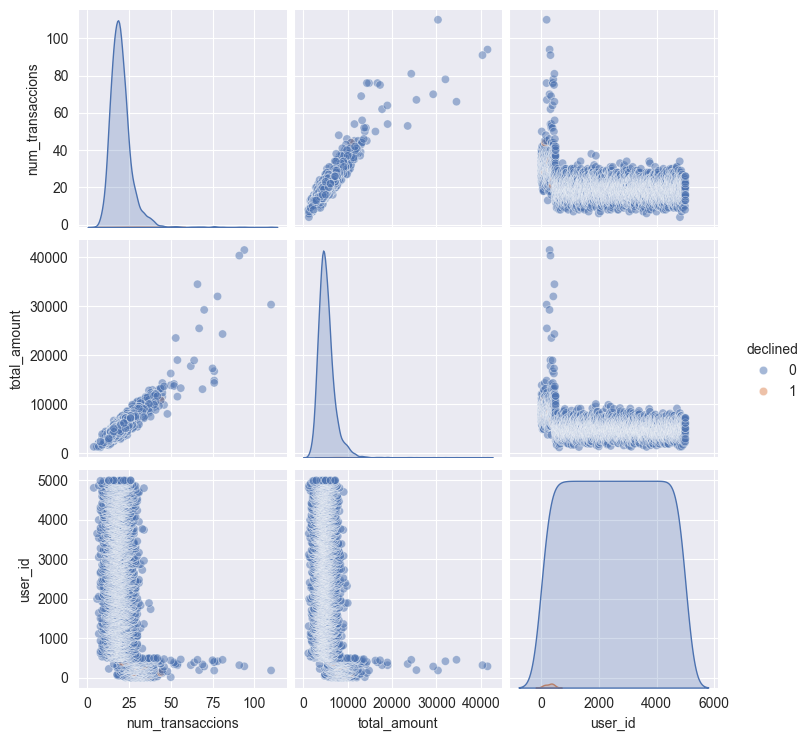

In [107]:
usuari_resum = transactions.groupby("user_id").agg(
    num_transaccions=("amount", "count"),
    total_amount=("amount", "sum"),
    declined=("declined", "first")
).reset_index()

sns.pairplot(usuari_resum[["num_transaccions", "total_amount", "user_id", "declined"]],
             hue="declined",
             diag_kind="kde",
             kind="scatter",
             plot_kws={"alpha": 0.5})

plt.show()
plt.close()


Mitjançant el pairplot de dues variables numèriques (num_transaccions i total_amount) 
amb el camp declined com a color, analitzem el comportament dels usuaris.

La diagonal confirma una distribució asimètrica amb cua llarga a la dreta: la majoria 
d'usuaris concentra poques transaccions i un import total baix, mentre uns pocs usuaris 
destaquen com a outliers amb volums molt superiors.

La relació entre num_transaccions i total_amount mostra una correlació positiva clara — 
com més transaccions, més import acumulat — cosa esperada i consistent amb les gràfiques anteriors.

Pel que fa al camp declined, els usuaris amb transaccions rebutjades (1) són molt minoritaris 
i no mostren un patró diferenciat respecte als no rebutjats (0).

# Nivell 2

## 1. Representa la correlació d'algunes variables i interpreta els resultats segons les teves dades.

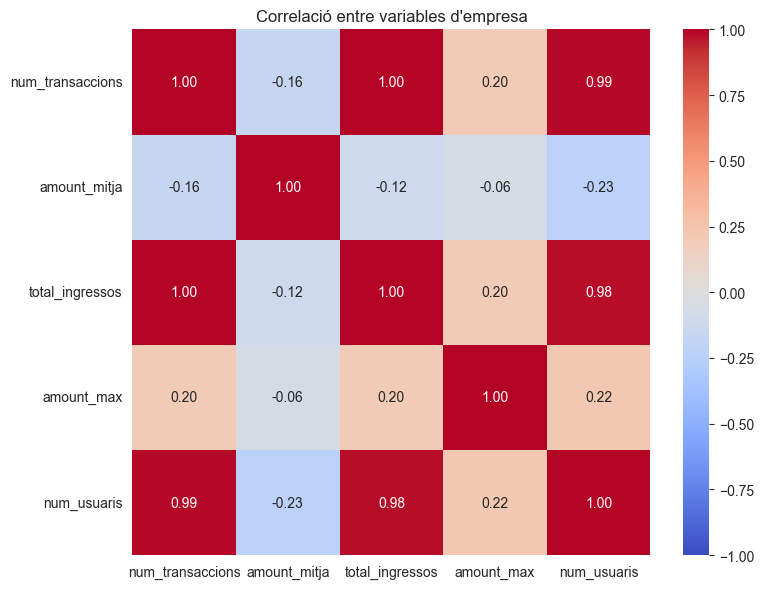

In [108]:
correlacio = empresa_resum2[["num_transaccions", "amount_mitja", "total_ingressos", "amount_max", "num_usuaris"]].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlacio, annot=True, fmt=".2f", cmap="coolwarm", 
            vmin=-1, vmax=1, ax=ax)

ax.set_title("Correlació entre variables d'empresa")
plt.tight_layout()
plt.show()

Mitjançant un heatmap de correlació, analitzem la relació entre les variables d'empresa.

S'observen correlacions molt fortes entre el nombre de transaccions i el total d'ingressos (1.00), ja que les transaccions es mouen en una mitjana similar, i és la quantitat d'aquestes, la que marca la diferencia en els totals. 

De manera similar, el nombre d'usuaris i el de transaccions mostren una correlació de 0.99, indicant que fora d'alguna discordança, estan alineades.

En canvi, la mitjana d'amount no presenta correlació significativa amb la resta de variables, suggerint que el ticket mitjà és independent del volum de negoci de l'empresa

## 2.  Implementa un Jointplot per explorar la relació entre dues variables i interpreta els resultats segons les teves dades.

In [109]:
users["birth_date"] = pd.to_datetime(users["birth_date"], format="%b %d, %Y")
users["edat"] = ((pd.Timestamp.now() - users["birth_date"]).dt.days // 365).astype(int)


In [110]:
user_compres = transactions.groupby("user_id")["amount"].sum().reset_index()
user_compres.columns = ["id", "total_compres"]

user_compres = user_compres.merge(users[["id", "edat"]], on="id", how="left")


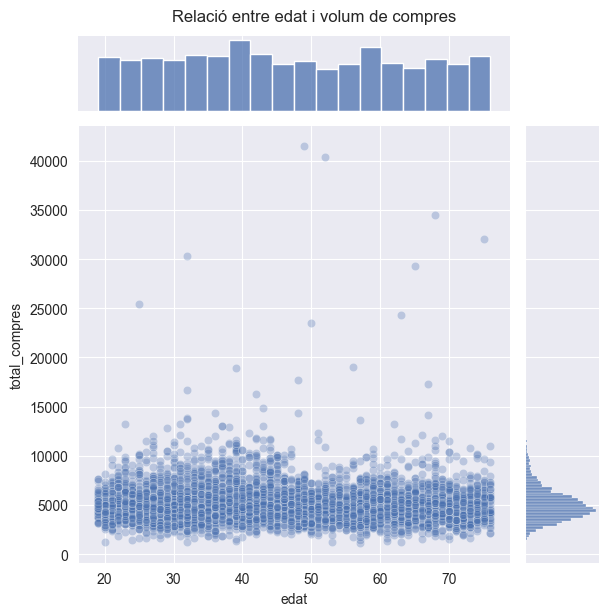

In [111]:
sns.jointplot(data=user_compres, 
              x="edat", 
              y="total_compres",
              alpha=0.3)

plt.suptitle("Relació entre edat i volum de compres", y=1.02)
plt.show()

Establim la relació entre el total de compres i l'edat dels usuaris, per aprofundir en la demografia dels clients.

Pel que fa a la distribució per edat, és relativament uniforme pel que fa a la desviació de la mitjana, amb pics alts clars sobre els 40 i 60 anys.
La distribució de compres és simètrica marcant la moda sobre els 5000$ per client, al llarg del total acumulat per l'usuari.

La gràfica de dispersió no mostra una correlació clara entre les dues variables, però sí que hi podem observar una tendència majoritària al voltant dels 5000$, coincidint amb l'histograma, i una major dispersió entre els 10k i el màxim de 45k ($).
